In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

### Alanyzing Data_full

In [ ]:
with open("F:/MyProjects/Zero-shot-Dynamic-Routing-System/data/data_full.json") as f:
    data_full = json.load(f)

In [11]:
data_full

{'oos_val': [['set a warning for when my bank account starts running low',
   'oos'],
  ['a show on broadway', 'oos'],
  ['who has the best record in the nfl', 'oos'],
  ['how do i find the area of a circle', 'oos'],
  ['how many onions do i have on hand', 'oos'],
  ['what is the name of the 13th president', 'oos'],
  ['show me recent activity in my backyard', 'oos'],
  ['how long will it take me to pay off my card if i pay an extra $50 a month over the minimum',
   'oos'],
  ['does our bank have free notary', 'oos'],
  ['what were the top stories this week', 'oos'],
  ['can i mix antifreeze with water', 'oos'],
  ['are any earning reports due', 'oos'],
  ['show me the channel guide', 'oos'],
  ['is the pnc bank open', 'oos'],
  ['where does the power steering fluid go', 'oos'],
  ['when was the last time the president visited floridau', 'oos'],
  ['how can i keep my windshield from fogging up in winter', 'oos'],
  ['how do i compute the median of a set of numbers', 'oos'],
  ['what is

In [13]:
df_val = pd.DataFrame(data_full['val'], columns=['utterance', 'intent'])
df_oos = pd.DataFrame(data_full['oos_val'], columns=['utterance', 'intent'])

In [14]:
df_combined = pd.concat([df_val, df_oos], ignore_index=True)

In [18]:
display(df_combined.shape)
df_combined.head()

(3100, 2)

,utterance,intent
0,"in spanish, meet me tomorrow is said how",translate
1,"in french, how do i say, see you later",translate
2,how do you say hello in japanese,translate
3,how do i ask about the weather in chinese,translate
4,"how can i say ""cancel my order"" in french",translate


In [25]:
print(f"Total In-Scope Validation Samples: {len(df_val)}")
print(f"Total Out-of-Scope Validation Samples: {len(df_oos)}")
print(f"Total Combined Samples: {len(df_combined)}")
print(f"Number of Unique In-Scope Intents: {df_val['intent'].nunique()}\n")

Total In-Scope Validation Samples: 3000
Total Out-of-Scope Validation Samples: 100
Total Combined Samples: 3100
Number of Unique In-Scope Intents: 150



In [ ]:

print(df_val['intent'].value_counts().head(10))

intent
translate                    20
transfer                     20
timer                        20
definition                   20
meaning_of_life              20
insurance_change             20
find_phone                   20
travel_alert                 20
pto_request                  20
improve_credit_score         20
fun_fact                     20
change_language              20
payday                       20
replacement_card_duration    20
time                         20
application_status           20
flight_status                20
flip_coin                    20
change_user_name             20
where_are_you_from           20
Name: count, dtype: int64


In [27]:
df_combined['word_count'] = df_combined['utterance'].apply(lambda x: len(x.split()))

In [28]:
print(df_combined['word_count'].describe())

count    3100.000000
mean        8.281935
std         3.421436
min         1.000000
25%         6.000000
50%         8.000000
75%        10.000000
max        24.000000
Name: word_count, dtype: float64


C:\Users\ritam\AppData\Local\Temp\ipykernel_2568\228454248.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=scope_counts, palette='Set2')


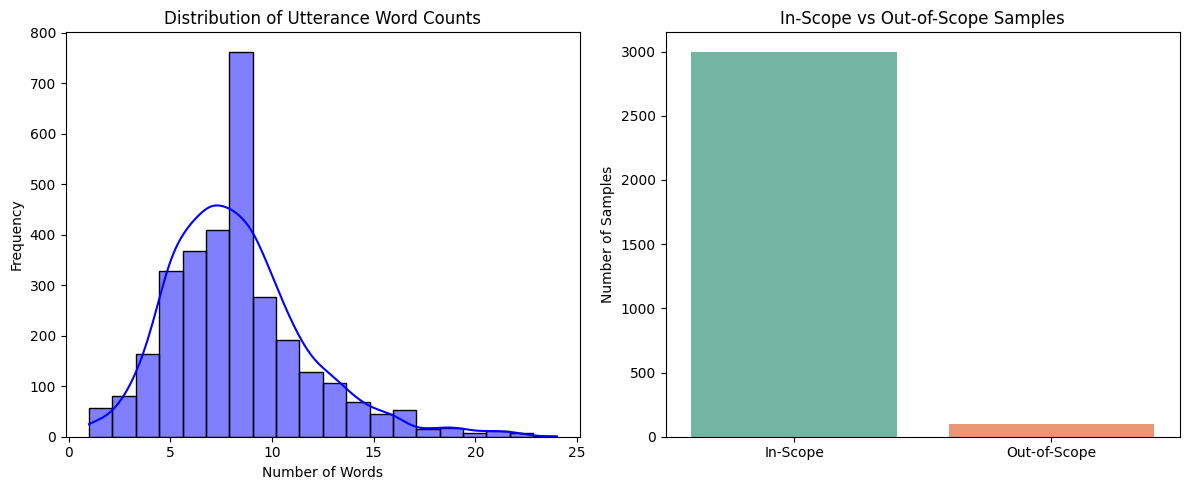

In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_combined['word_count'], bins=20, kde=True, color='blue')
plt.title('Distribution of Utterance Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')


plt.subplot(1, 2, 2)
scope_counts = ['In-Scope' for _ in range(len(df_val))] + ['Out-of-Scope' for _ in range(len(df_oos))]
sns.countplot(x=scope_counts, palette='Set2')
plt.title('In-Scope vs Out-of-Scope Samples')
plt.ylabel('Number of Samples')

plt.tight_layout()
plt.show()